---
>Installing packages:

In [85]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


-- importing necessary libraries--

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



---
>1: Dataset Loading and Initial Exploration

In [87]:
# Load the dataset
df = pd.read_csv('insurance.csv')

# View the first 5 rows
print(df.head())

# Check the data types and look for missing values
print(df.info())

# Summary of numerical columns (mean, std, min, max, etc.)
print(df.describe())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   

---
>2: Data preprocessing (Missing Values, Encode Categorical Variables, and Feature Scaling  )

In [88]:
# How many missing values exist in each column
print(df.isnull().sum())
# Turned out there are no missing values in the dataset, therefore we can proceed with the analysis without needing to handle missing data.

# Encoding categorical variables
# Using LabelEncoder for 'sex','smoker' and OneHotEncoder for 'region'
le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])
le_smoker = LabelEncoder()
df['smoker'] = le_smoker.fit_transform(df['smoker'])

# One-hot encoding for 'region'
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

print(df.head())



age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 1   
4   32    1  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [89]:

# Feature scaling
scaler = StandardScaler()
numerical_features = ['age', 'bmi', 'children']
df[numerical_features] = scaler.fit_transform(df[numerical_features])
print(df[numerical_features].head())


        age       bmi  children
0 -1.438764 -0.453320 -0.908614
1 -1.509965  0.509621 -0.078767
2 -0.797954  0.383307  1.580926
3 -0.441948 -1.305531 -0.908614
4 -0.513149 -0.292556 -0.908614


---
>3: Dataset Preparation for Machine Learning (train/test datasets)

In [90]:
# Separate features and target using iloc
X = df.drop('charges', axis=1)
y = df['charges']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 1070 samples
Testing set size: 268 samples


--- 
>4: Implement Multiple Regression Models


In [91]:
# 1.Simple Linear Regression  

# Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

In [92]:
# 2.Polynomial Regression

# Create polynomial features(degree=2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train the polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predictions
y_pred_poly = poly_model.predict(X_test_poly)

In [93]:
# 3.Random Forest Regression
# much more accurate for this datasets

# Initializing with 100 trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

---
>5: Model Evaluation and Comparison

In [94]:
# Function to calculate and return metrics
def get_metrics(y_true, y_pred): #y_true is the actual values(y_test)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse

# Metrics for all 3 models
results = {
    'Linear Regression': get_metrics(y_test, y_pred_lr),
    'Polynomial Regression': get_metrics(y_test, y_pred_poly),
    'Random Forest': get_metrics(y_test, y_pred_rf)
}

# A comparison table
comparison_df = pd.DataFrame(results, index=['R2 Score', 'MAE', 'RMSE']).T
print(comparison_df)

                       R2 Score          MAE         RMSE
Linear Regression      0.783593  4181.194474  5796.284659
Polynomial Regression  0.866583  2729.500134  4551.132385
Random Forest          0.865515  2545.834491  4569.305441


---
> 6: Visualization: Actual vs. Predicted

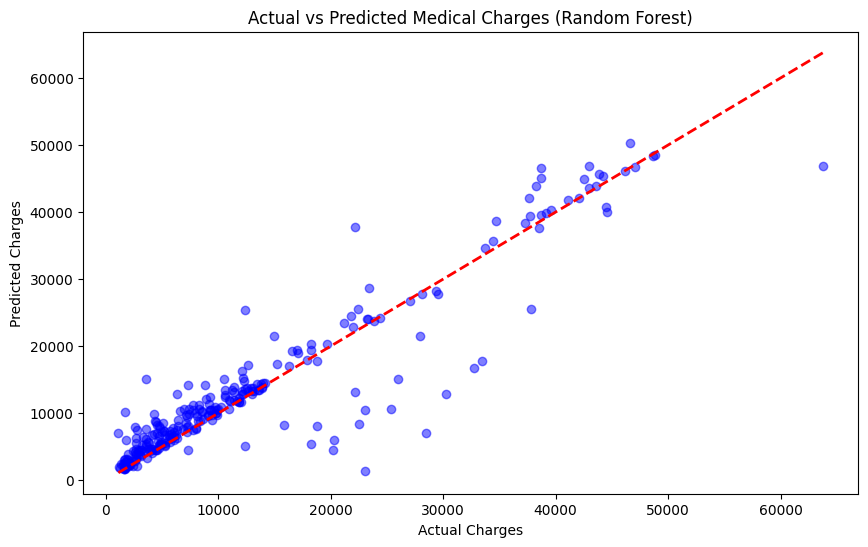

In [95]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='blue') # Using RF as example
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Medical Charges (Random Forest)')
plt.show()